In [1]:
import os
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

from torch.utils.data import DataLoader


# change the path for our use
data_path = '/home/vcohen/cope/data/'


print(f"Data path: {data_path}")


Data path: /home/vcohen/cope/data/


In [2]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import data_processing, compute_anomalies_and_scalers, \
                            compute_forced_response, \
                            numpy_to_torch, merge_models_and_runs, rescale_training_set, stack_models_and_runs

from trend_vae import Trend_Vae


In [3]:
# Use MPS / Cuda or CPU if none of the options are available
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
np.random.seed(42)

Using device: cpu


In [4]:
############### Load climate model raw data for SST
with open('data/ssp585_time_series.pkl', 'rb') as f:
    data = pickle.load(f)

###################### Load longitude and latitude 
with open('data/lon.npy', 'rb') as f:
    lon = np.load(f)

with open('data/lat.npy', 'rb') as f:
    lat = np.load(f)

# define grid (+ croping for latitude > 60)
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')

lat_size = lat_grid.shape[0]
lon_size = lon_grid.shape[1]

In [5]:
# define pytorch precision
dtype = torch.float32

time_length = 165

data_processed, notnan_idx, nan_idx = data_processing(data, lon, lat,max_models=100)
x, means, vars = compute_anomalies_and_scalers(data_processed, lon_size, lat_size, nan_idx, time_period=time_length)
y = compute_forced_response(x, lon_size, lat_size, nan_idx, time_period=time_length)
x,y, means, vars = numpy_to_torch(x,y,means,vars, dtype=dtype)

/home/vcohen/cope/src/preprocessing.py:98: RuntimeWarning: Degrees of freedom <= 0 for slice.
  vars[m] = np.nanvar(data_reshaped[m],axis=(0))
/home/vcohen/cope/src/preprocessing.py:103: RuntimeWarning: Mean of empty slice
  data_reshaped[m] = data_reshaped[m] - np.expand_dims(np.nanmean(data_reshaped[m],axis=1),axis=1).repeat(data_reshaped[m].shape[1],axis=1)
/home/vcohen/cope/src/preprocessing.py:153: RuntimeWarning: Mean of empty slice
  data_forced_response[m] = np.expand_dims(np.nanmean(data[m],axis=0),axis=0).repeat(data[m].shape[0],axis=0)


In [6]:
m0 = 'GISS-E2-2-G'  # use the first model as a reference

training_models, x_rescaled, y_rescaled = rescale_training_set(m0,x,y,means,vars,dtype=dtype)
training_models, x_train, y_train, x_test, y_test  = merge_models_and_runs(m0,x_rescaled,y_rescaled,means,vars,dtype=dtype)
x_stacked, y_stacked = stack_models_and_runs(training_models, x_rescaled, y_rescaled)


x_tmp = x_stacked.view(-1, x_stacked.shape[2])
y_tmp = y_stacked.view(-1, y_stacked.shape[2])

In [7]:
from torch.utils.data import Dataset

class ClimateDataset(Dataset):
    def __init__(self, inputs, outputs):
        self.inputs = inputs
        self.outputs = outputs

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, idx):
        return self.inputs[idx], self.outputs[idx]

# Create the dataset
train_dataset = ClimateDataset(x_stacked[:,:,notnan_idx], y_stacked[:,:,notnan_idx])
test_dataset = ClimateDataset(x_rescaled[m0][:,:,notnan_idx], y_rescaled[m0][:,:,notnan_idx])

# Create the DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check the shape of the data
sample = next(iter(train_loader))
print(f"Input shape: {sample[0].shape}, Output shape: {sample[1].shape}")


Input shape: torch.Size([32, 165, 1531]), Output shape: torch.Size([32, 165, 1531])


In [8]:
sample = next(iter(train_loader))

# Set VAE parameters
hidden_dim = 128 # Increased for better representation
feat_dim = len(notnan_idx)
latent_dim = 64 # Intermediate layer size
z_dim = 5 # Actual latent space dimension
trend_poly = 2
# seq_len, _ = sample
seq_len = sample[0].shape[1]  # Sequence length from the input data
print(f"The sequence length is {seq_len}")
# beta = 0.001      # Weight for KL divergence term -- not used in this version

# Create the model
vae_model = Trend_Vae(
    seq_len=seq_len,
    feat_dim=feat_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    z_dim=z_dim,
    trend_poly=trend_poly,
    use_residual_conn=True,
    device=device,
).to(device)

# Print model summary
print("\nTrend VAE Model Architecture:")
print(vae_model)
print(f"\nTotal parameters: {sum(p.numel() for p in vae_model.parameters() if p.requires_grad):,}")

The sequence length is 165

Trend VAE Model Architecture:
Trend_Vae(
  (encoder): TrendVAEEncoder(
    (encoder): Sequential(
      (0): Conv1d(1531, 128, kernel_size=(3,), stride=(2,), padding=(1,))
      (1): ReLU()
      (2): Conv1d(128, 64, kernel_size=(3,), stride=(2,), padding=(1,))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (z_mean): Linear(in_features=2688, out_features=5, bias=True)
    (z_log_var): Linear(in_features=2688, out_features=5, bias=True)
  )
  (decoder): TrendVAEDecoder(
    (level_model): LevelModel(
      (level_dense1): Linear(in_features=5, out_features=1531, bias=True)
      (level_dense2): Linear(in_features=1531, out_features=1531, bias=True)
      (relu): ReLU()
    )
    (trend_layer): TrendLayer(
      (trend_dense1): Linear(in_features=5, out_features=3062, bias=True)
      (trend_dense2): Linear(in_features=3062, out_features=3062, bias=True)
    )
    (residual_conn): ResidualConnection(
      (fc): Linear(in_features=5, o

In [9]:
for batch in train_loader:
    print(len(batch))
    u = batch[0].to(device)  # Shape: (N, T, D)
    v = batch[1].to(device)  # Shape: (N, T, D)
    print(u.shape)
    print(v.shape)

2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([32, 165, 1531])
torch.Size([32, 165, 1531])
2
torch.Size([

In [10]:
from trend_vae import train_vae
# Train the VAE
epochs = 200
losses = []

optimizer = torch.optim.Adam(vae_model.parameters(), lr=3e-4) # Weight decay is not used in this version (was weight_decay=1e-5)

losses = train_vae(vae_model, train_loader, optimizer, epochs=epochs, device=device)

  0%|          | 1/200 [00:02<07:39,  2.31s/it]

Epoch 1, Loss: 74485516.2137


  6%|▌         | 11/200 [00:24<07:00,  2.22s/it]

Epoch 11, Loss: 34263497.4395


 10%|█         | 21/200 [00:46<06:24,  2.15s/it]

...

 90%|█████████ | 181/200 [06:37<00:41,  2.19s/it]

Epoch 181, Loss: 4973421.1665


 96%|█████████▌| 191/200 [06:59<00:19,  2.20s/it]

Epoch 191, Loss: 3996833.1181


100%|██████████| 200/200 [07:18<00:00,  2.19s/it]


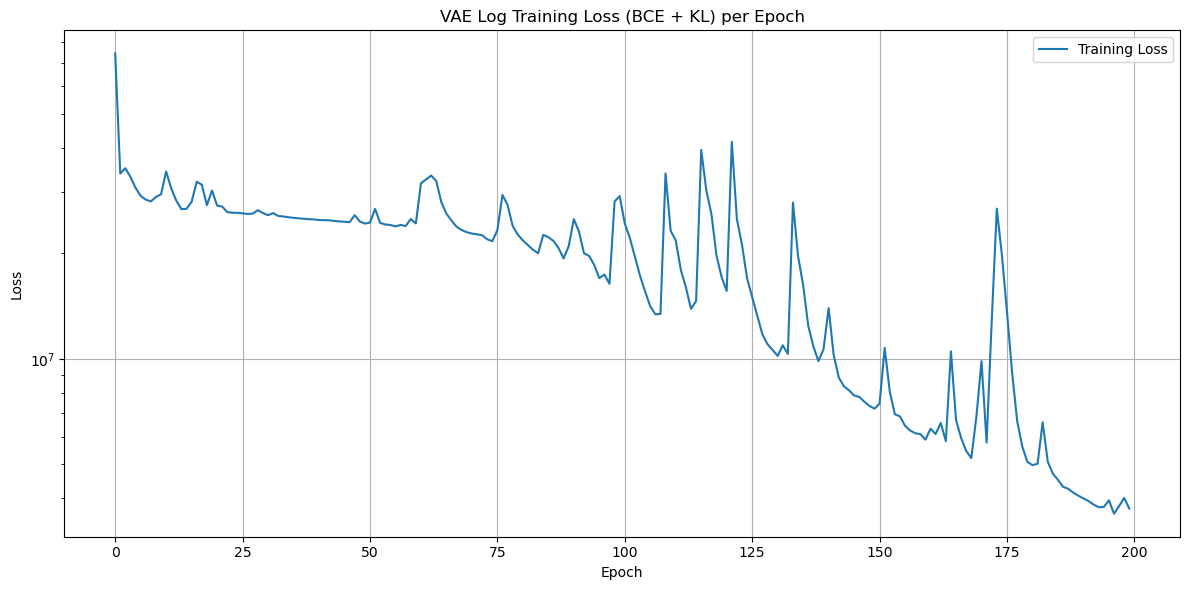

Final loss value: 3738857.973032


In [11]:
# Plot the training loss
plt.figure(figsize=(12, 6))
plt.plot(losses, label='Training Loss')
plt.legend()
plt.title('VAE Log Training Loss (BCE + KL) per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.yscale('log')  # Using log scale to better visualize the decreasing loss
plt.tight_layout()
plt.show()

# Print the final loss value
print(f"Final loss value: {losses[-1]:.6f}")

In [32]:
# Set VAE to evaluation mode
vae_model.eval()

# # Create a directory for saving animations if it doesn't exist
# animation_dir = os.path.join('outputs', 'trend', 'vae')
# os.makedirs(animation_dir, exist_ok=True)
# print(f"Animations will be saved to: {animation_dir}")

# Get ground truth for the test model
ground_truth = y_rescaled[m0]

# Store predictions for visualization
predictions = {}
mse_values = np.zeros(y_rescaled[m0].shape[0])  # Initialize MSE values for each run

# Generate predictions for each selected run
for idx in range(y_rescaled[m0].shape[0]):
    # Get the run data
    run_data = y_rescaled[m0][idx,:,notnan_idx]  # Shape (165, 6523)
    
    # Convert to torch tensor
    input_tensor = torch.tensor(run_data, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 165, 6523)
    
    # Make prediction with the VAE
    with torch.no_grad():
        # Forward pass through the VAE
        reconstructed, mu, log_var = vae_model(input_tensor)  # Output shape: (1, 165, 6523)
        prediction = reconstructed.squeeze(0).cpu().numpy()  # Remove batch dimension, shape: (165, 6523)
    
    # Store prediction

    # Calculate MSE
    mse = np.sum((prediction - ground_truth[idx,:,notnan_idx].detach().numpy()) ** 2)/ np.sum(ground_truth[idx,:,notnan_idx].detach().numpy()**2 ) # Normalized MSE
    mse_values[idx] = mse
    # print(f"MSE for {test_model} - {run}: {mse:.4f}")

# Print average MSE across all selected runs
print(f"\nAverage MSE across all selected runs: {np.mean(mse_values):.4f}")


Average MSE across all selected runs: 13.3190


/tmp/ipykernel_49087/2698611.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(run_data, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 165, 6523)


In [29]:
prediction

array([[-0.10865507, -0.40876263, -0.5726541 , ..., -1.2030878 ,
        -0.75757265, -0.7679297 ],
       [-0.48172385, -0.12828313, -0.6417563 , ..., -0.79925305,
        -0.9370413 , -0.5177525 ],
       [-0.18329437, -0.37319186, -0.3509236 , ..., -0.9028914 ,
        -1.0576249 , -0.8755396 ],
       ...,
       [ 0.6473268 ,  0.27339765, -0.23571108, ...,  1.4533608 ,
         1.4287963 ,  1.4880205 ],
       [ 1.061746  ,  0.39845735, -0.198613  , ...,  1.8789802 ,
         1.3147957 ,  1.7256906 ],
       [ 0.8442395 ,  0.56050926, -0.12467318, ...,  1.6866784 ,
         1.6711099 ,  1.220348  ]], dtype=float32)